# 04 - Evaluation & Business Translation
Perubahan dari versi sebelumnya:
- Load model final & threshold dari model_metadata.json (tidak hardcode)
- SHAP diganti dengan koefisien LR (lebih tepat untuk Logistic Regression)
- Business translation menggunakan threshold optimal dari metadata

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    classification_report, fbeta_score, precision_recall_curve
)

sns.set_style("whitegrid")

In [2]:
with open("data/model_metadata.json", "r") as f:
    metadata = json.load(f)

MODEL_NAME = metadata["model_name"]
THRESHOLD  = metadata["threshold"]

print(f"Model final  : {MODEL_NAME}")
print(f"Threshold    : {THRESHOLD}")
print(f"Recall       : {metadata['recall']:.1%}")
print(f"ROC-AUC      : {metadata['roc_auc']}")
print(f"False Negative: {metadata['fn']}")

Model final  : XGBoost
Threshold    : 0.25
Recall       : 94.4%
ROC-AUC      : 0.8475
False Negative: 21


In [3]:
X_train = pd.read_csv("data/X_train.csv")
X_test  = pd.read_csv("data/X_test.csv")
y_train = pd.read_csv("data/y_train.csv").squeeze()
y_test  = pd.read_csv("data/y_test.csv").squeeze()

model   = joblib.load("data/model_final.pkl")
y_proba = np.load("data/y_proba_final.npy")
y_pred  = (y_proba >= THRESHOLD).astype(int)

# ============================================================

## 1. Confusion Matrix

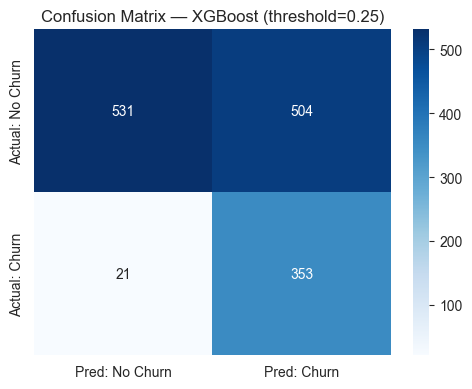


True Negative  (benar tidak churn) : 531
False Positive (false alarm)        : 504
False Negative (churn terlewat)     : 21  ← ingin diminimalkan
True Positive  (benar churn)        : 353

              precision    recall  f1-score   support

           0       0.96      0.51      0.67      1035
           1       0.41      0.94      0.57       374

    accuracy                           0.63      1409
   macro avg       0.69      0.73      0.62      1409
weighted avg       0.82      0.63      0.64      1409



In [4]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: No Churn", "Pred: Churn"],
    yticklabels=["Actual: No Churn", "Actual: Churn"]
)
plt.title(f"Confusion Matrix — {MODEL_NAME} (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

print(f"\nTrue Negative  (benar tidak churn) : {tn}")
print(f"False Positive (false alarm)        : {fp}")
print(f"False Negative (churn terlewat)     : {fn}  ← ingin diminimalkan")
print(f"True Positive  (benar churn)        : {tp}")
print(f"\n{classification_report(y_test, y_pred)}")

# ============================================================

## 2. ROC Curve & Precision-Recall Curve

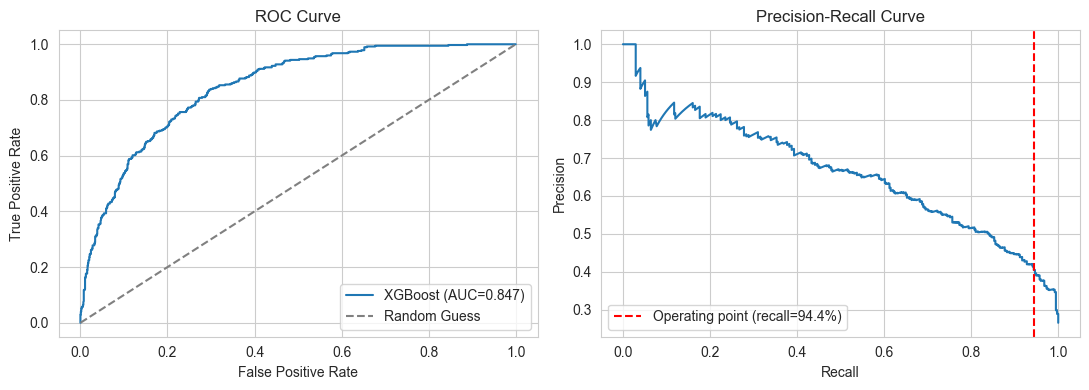

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f"{MODEL_NAME} (AUC={auc_score:.3f})")
axes[0].plot([0,1],[0,1], "--", color="gray", label="Random Guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall Curve
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec_arr, prec_arr)
axes[1].axvline(metadata["recall"], color="red", linestyle="--",
                label=f"Operating point (recall={metadata['recall']:.1%})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================

## 3. Model Interpretation

Untuk Logistic Regression, interpretasi terbaik adalah melalui
KOEFISIEN MODEL — bukan feature importance (itu untuk tree-based)
dan bukan SHAP TreeExplainer (itu untuk tree-based).

Koefisien LR = log-odds. Nilai positif berarti fitur tersebut
meningkatkan probabilitas churn; negatif berarti menurunkannya.
exp(koefisien) = odds ratio -> lebih mudah diinterpretasi secara bisnis.
============================================================

In [6]:
# PERBAIKAN: fitur numerik (tenure, MonthlyCharges, TotalCharges) skalanya
# jauh berbeda dari fitur dummy 0/1 hasil one-hot encoding. Membandingkan
# abs(coefficient) mentah antar fitur dengan skala berbeda menyesatkan --
# fitur numerik bisa ter-under/over-estimate pengaruhnya.
#
# Solusi: standardisasi koefisien (coef * std fitur di training data).
# Ini SETARA dengan melatih model di atas fitur yang sudah di-scale,
# tapi TANPA perlu retrain -- prediksi model sama sekali tidak berubah,
# hanya skala pembanding "seberapa besar pengaruh tiap fitur" jadi adil.
feature_std = pd.read_csv("data/X_train_std.csv", index_col=0).squeeze()

coef = pd.Series(model.coef_[0], index=X_train.columns)
coef_std = coef * feature_std  # koefisien terstandarisasi (untuk ranking & plot)

coef_sorted = coef_std.abs().sort_values(ascending=False).head(15)
top_features = coef_sorted.index
top_coef = coef_std[top_features].sort_values()

# Odds ratio tetap pakai koefisien ASLI (bukan yang distandarisasi) karena
# interpretasi odds ratio harus dalam satuan asli fitur (mis. per 1 bulan tenure),
# bukan per unit standar deviasi.
odds_ratio = np.exp(coef[top_features]).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Koefisien (log-odds)
colors = ["#d62728" if v > 0 else "#1f77b4" for v in top_coef.values]
axes[0].barh(top_coef.index, top_coef.values, color=colors)
axes[0].axvline(0, color="gray", linewidth=0.8)
axes[0].set_title(f"Top 15 Koefisien (Terstandarisasi) — {MODEL_NAME}\n"
                   "(Merah = dorong Churn, Biru = dorong No Churn)")
axes[0].set_xlabel("Standardized Log-Odds Coefficient (coef × std fitur)")

# Plot 2: Odds Ratio
or_sorted = odds_ratio.sort_values()
colors2 = ["#d62728" if v > 1 else "#1f77b4" for v in or_sorted.values]
axes[1].barh(or_sorted.index, or_sorted.values, color=colors2)
axes[1].axvline(1, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_title("Odds Ratio per Fitur\n(>1 = meningkatkan risiko churn)")
axes[1].set_xlabel("Odds Ratio (exp(coefficient))")

plt.tight_layout()
plt.show()

AttributeError: Coefficients are not defined for Booster type None

In [ ]:
or_table = pd.DataFrame({
    "Feature":     odds_ratio.sort_values(ascending=False).index,
    "Coefficient": coef[odds_ratio.sort_values(ascending=False).index].round(4).values,
    "Odds_Ratio":  odds_ratio.sort_values(ascending=False).round(4).values,
    "Interpretation": [
        "meningkatkan risiko churn" if v > 1 else "menurunkan risiko churn"
        for v in odds_ratio.sort_values(ascending=False).values
    ]
})
print("\nTop 15 Fitur — Koefisien & Odds Ratio:")
print(or_table.to_string(index=False))


Top 15 Fitur — Koefisien & Odds Ratio:
                       Feature  Coefficient  Odds_Ratio            Interpretation
   InternetService_Fiber optic       0.5222      1.6858 meningkatkan risiko churn
MultipleLines_No phone service       0.4945      1.6397 meningkatkan risiko churn
            tenure_group_49-60       0.4181      1.5191 meningkatkan risiko churn
PaymentMethod_Electronic check       0.2922      1.3394 meningkatkan risiko churn
               StreamingTV_Yes       0.2725      1.3133 meningkatkan risiko churn
             MultipleLines_Yes       0.2667      1.3057 meningkatkan risiko churn
                MonthlyCharges       0.0135      1.0136 meningkatkan risiko churn
                  TotalCharges       0.0001      1.0001 meningkatkan risiko churn
                        tenure      -0.0439      0.9570   menurunkan risiko churn
                  num_services      -0.1299      0.8782   menurunkan risiko churn
               TechSupport_Yes      -0.2863      0.7511   

Cara membaca Odds Ratio:
- OR > 1: fitur ini meningkatkan risiko churn. Contoh OR=2.5 artinya
  customer dengan fitur ini 2.5x lebih mungkin churn dibanding baseline.
- OR < 1: fitur ini menurunkan risiko churn. Contoh OR=0.3 artinya
  customer dengan fitur ini hanya 0.3x (lebih kecil) kemungkinan churn.
- OR = 1: fitur tidak berpengaruh pada probabilitas churn.

============================================================

## 4. Threshold Tuning Summary

In [ ]:
rows = []
for t in [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]:
    pt  = (y_proba >= t).astype(int)
    cmt = confusion_matrix(y_test, pt)
    tnt, fpt, fnt, tpt = cmt.ravel()
    rec  = tpt / (tpt + fnt) if (tpt + fnt) > 0 else 0
    prec = tpt / (tpt + fpt) if (tpt + fpt) > 0 else 0
    f2   = fbeta_score(y_test, pt, beta=2)
    rows.append({
        "threshold": t,
        "recall": round(rec, 3),
        "precision": round(prec, 3),
        "f2": round(f2, 3),
        "FN": fnt,
        "FP": fpt,
        "selected": "← DIPILIH" if t == THRESHOLD else ""
    })

thr_table = pd.DataFrame(rows)
print("\nTrade-off di berbagai threshold:")
print(thr_table.to_string(index=False))

# ============================================================


Trade-off di berbagai threshold:
 threshold  recall  precision    f2  FN  FP  selected
      0.50   0.789      0.503 0.708  79 291          
      0.45   0.837      0.488 0.732  61 329          
      0.40   0.890      0.470 0.755  41 375          
      0.35   0.914      0.447 0.756  32 423          
      0.30   0.925      0.424 0.748  28 471 ← DIPILIH
      0.25   0.941      0.413 0.749  22 501          
      0.20   0.963      0.394 0.747  14 554          


## 5. Business Translation
============================================================

In [ ]:
risk_df = pd.DataFrame({
    "actual_churn":    y_test.values,
    "churn_proba":     y_proba,
    "monthly_charges": X_test["MonthlyCharges"].values
})

def segment(p):
    if p >= 0.6:
        return "High Risk"
    elif p >= 0.35:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["segment"] = risk_df["churn_proba"].apply(segment)

summary = risk_df.groupby("segment").agg(
    jumlah_customer   = ("actual_churn", "count"),
    actual_churn_rate = ("actual_churn", "mean"),
    avg_monthly_charges = ("monthly_charges", "mean")
).reindex(["High Risk", "Medium Risk", "Low Risk"]).round(3)

print("\nRisk Segmentation:")
print(summary)

# Validasi: churn rate harus monotonically decreasing High -> Medium -> Low
rates = summary["actual_churn_rate"].values
monotonic = all(rates[i] >= rates[i+1] for i in range(len(rates)-1)
                if not np.isnan(rates[i]) and not np.isnan(rates[i+1]))
print(f"\nMonotonic churn rate (validasi segmentasi): {'✓ Valid' if monotonic else '✗ Perlu review'}")


Risk Segmentation:
             jumlah_customer  actual_churn_rate  avg_monthly_charges
segment                                                             
High Risk                476              0.563               77.790
Medium Risk              289              0.256               61.712
Low Risk                 644              0.050               55.028

Monotonic churn rate (validasi segmentasi): ✓ Valid


In [ ]:
high_risk        = risk_df[risk_df["segment"] == "High Risk"]
high_risk_churn  = high_risk[high_risk["actual_churn"] == 1]

success_rate     = 0.30
n_saved          = len(high_risk_churn) * success_rate
monthly_saved    = n_saved * high_risk_churn["monthly_charges"].mean() if len(high_risk_churn) > 0 else 0
annual_saved     = monthly_saved * 12

print(f"\nBusiness Impact Estimation:")
print(f"Customer High Risk              : {len(high_risk)}")
print(f"...yang benar-benar churn       : {len(high_risk_churn)}")
print(f"Estimasi terselamatkan (30%)    : {n_saved:.1f} customer")
print(f"Revenue terselamatkan / bulan   : ${monthly_saved:,.2f}")
print(f"Revenue terselamatkan / tahun   : ${annual_saved:,.2f}")


Business Impact Estimation:
Customer High Risk              : 476
...yang benar-benar churn       : 268
Estimasi terselamatkan (30%)    : 80.4 customer
Revenue terselamatkan / bulan   : $6,189.39
Revenue terselamatkan / tahun   : $74,272.68


## Ringkasan Akhir Project

Model Final : {MODEL_NAME}
Threshold   : {THRESHOLD}
ROC-AUC     : {metadata['roc_auc']}
Recall      : {metadata['recall']:.1%} ({tp} dari {tp+fn} customer churn terdeteksi)
False Neg   : {fn} customer churn tidak terdeteksi
False Pos   : {fp} false alarm (dapat retention offer tidak perlu)
Precision   : {metadata['precision']:.1%}

Rekomendasi Bisnis:
1. Fokus retention campaign pada segmen High Risk (probabilitas >= 0.6)
2. Tawarkan migrasi kontrak month-to-month -> tahunan dengan insentif
   (Contract_Two year adalah faktor protektif terkuat, odds ratio jauh < 1)
3. Program onboarding/loyalty untuk pelanggan baru (tenure rendah)
4. Evaluasi pricing/kualitas layanan Fiber optic
5. Dorong migrasi dari Electronic check ke pembayaran otomatis